In [3]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [4]:
dataset=pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
y = dataset["Exited"]
x = dataset.iloc[:, 3:13].copy()

# --- ratio features ---
x["BalanceSalaryRatio"] = x["Balance"] / (x["EstimatedSalary"] + 1)
x["TenureByAge"]        = x["Tenure"] / x["Age"]
x["CreditScoreByAge"]   = x["CreditScore"] / x["Age"]

# --- binary flags ---
x["ZeroBalance"]           = (x["Balance"] == 0).astype(int)
x["IsSenior"]              = (x["Age"] >= 60).astype(int)
x["IsNewCustomer"]         = (x["Tenure"] == 0).astype(int)          # brand-new, no loyalty
x["HasBalance_Inactive"]   = (                                        # classic churn signal
    (x["Balance"] > 0) & (x["IsActiveMember"] == 0)
).astype(int)

# --- interaction features ---
x["Age_x_Active"]          = x["Age"] * x["IsActiveMember"]
x["Products_x_Active"]     = x["NumOfProducts"] * x["IsActiveMember"]

# --- age bins → one-hot ---
x["AgeBin"] = pd.cut(x["Age"], bins=[0, 30, 45, 60, 100],
                     labels=["Young", "Adult", "MidAge", "Senior"])
age_dummies = pd.get_dummies(x["AgeBin"], prefix="Age", drop_first=True)

# NumOfProducts is non-monotonic → categorical
prod_dummies = pd.get_dummies(x["NumOfProducts"], prefix="Products", drop_first=True)

# Geography & Gender → one-hot
geo_dummies    = pd.get_dummies(x["Geography"], prefix="Geo",    drop_first=True)
gender_dummies = pd.get_dummies(x["Gender"],    prefix="Gender", drop_first=True)

x = pd.concat([x, age_dummies, prod_dummies, geo_dummies, gender_dummies], axis=1)
x = x.drop(["Geography", "Gender", "AgeBin", "NumOfProducts"], axis=1)

print(x.shape)
print("New features added: IsNewCustomer, HasBalance_Inactive, Products_x_Active")

(10000, 25)
New features added: IsNewCustomer, HasBalance_Inactive, Products_x_Active


In [6]:
x.head()

,CreditScore,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreByAge,...,Products_x_Active,Age_Adult,Age_MidAge,Age_Senior,Products_2,Products_3,Products_4,Geo_Germany,Geo_Spain,Gender_Male
0,619,42,2,0.00,1,1,101348.88,0.000000,0.047619,14.738095,...,1,True,False,False,False,False,False,False,False,False
1,608,41,1,83807.86,0,1,112542.58,0.744670,0.024390,14.829268,...,1,True,False,False,False,False,False,False,True,False
2,502,42,8,159660.80,1,0,113931.57,1.401362,0.190476,11.952381,...,0,True,False,False,False,True,False,False,False,False
3,699,39,1,0.00,0,0,93826.63,0.000000,0.025641,17.923077,...,0,True,False,False,True,False,False,False,False,False
4,850,43,2,125510.82,1,1,79084.10,1.587035,0.046512,19.767442,...,1,True,False,False,False,False,False,False,True,False


In [7]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [8]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the ~20% churn ratio identical in train and test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0, stratify=y
)
print(f"Train churn rate: {y_train.mean():.3f}  |  Test churn rate: {y_test.mean():.3f}")

Train churn rate: 0.204  |  Test churn rate: 0.203


In [9]:
# feature scaling

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [10]:
x_train

array([[-1.24021723,  0.77986083,  0.35390313, ..., -0.57812007,
        -0.57504086, -1.09665089],
       [ 0.75974873, -0.27382717,  0.35390313, ...,  1.72974448,
        -0.57504086,  0.91186722],
       [-1.72725557, -0.9443559 , -0.3390904 , ..., -0.57812007,
        -0.57504086, -1.09665089],
       ...,
       [-0.51484098,  0.87565065,  1.39339343, ...,  1.72974448,
        -0.57504086,  0.91186722],
       [ 0.73902369, -0.36961699, -1.03208393, ..., -0.57812007,
        -0.57504086, -1.09665089],
       [ 0.95663657, -1.32751517,  0.35390313, ..., -0.57812007,
         1.73900686,  0.91186722]])

In [11]:
x_test

array([[-1.975956  ,  0.1093321 ,  0.35390313, ...,  1.72974448,
        -0.57504086, -1.09665089],
       [ 0.64576103, -1.42330499,  0.7003999 , ...,  1.72974448,
        -0.57504086, -1.09665089],
       [ 0.12763513,  2.40828774,  0.35390313, ..., -0.57812007,
         1.73900686,  0.91186722],
       ...,
       [-1.20912968,  0.20512192,  1.39339343, ..., -0.57812007,
        -0.57504086,  0.91186722],
       [ 1.10171182,  1.54617938,  1.39339343, ..., -0.57812007,
         1.73900686, -1.09665089],
       [ 0.9773616 , -0.75277626, -0.68558716, ..., -0.57812007,
         1.73900686, -1.09665089]])

In [12]:
x_train.shape

(8000, 25)

In [13]:
x_test.shape

(2000, 25)

In [14]:
#Creating ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [15]:
#initialising ANN
classifier=Sequential()

In [16]:
#adding input layer
classifier.add(Dense(units=x_train.shape[1],activation='relu'))

In [17]:
#adding first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))

In [18]:
#classifier the second hidden layer and adding dropout layer
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.3))

In [19]:
#adding output layer
classifier.add(Dense(1,activation='sigmoid'))

In [20]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
#early stopping----Stop training when a monitored metric has stopped improving.
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [22]:
model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7606 - loss: 0.5745 - val_accuracy: 0.8493 - val_loss: 0.4074
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8352 - loss: 0.4138 - val_accuracy: 0.8569 - val_loss: 0.3575
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8451 - loss: 0.3929 - val_accuracy: 0.8576 - val_loss: 0.3536
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8438 - loss: 0.3831 - val_accuracy: 0.8557 - val_loss: 0.3516
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8490 - loss: 0.3744 - val_accuracy: 0.8561 - val_loss: 0.3513
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8500 - loss: 0.3731 - val_accuracy: 0.8595 - val_loss: 0.3487
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8494 - loss: 0.3650 - val_accuracy: 0.8603 - val_loss: 0.3497
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8464 - loss: 0.3650 - 

In [23]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

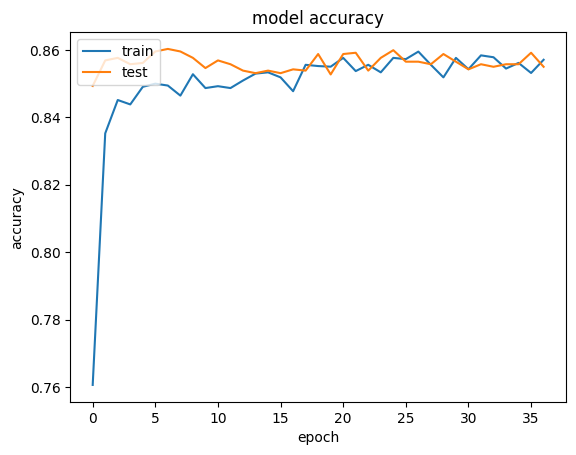

In [24]:
#summarise history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

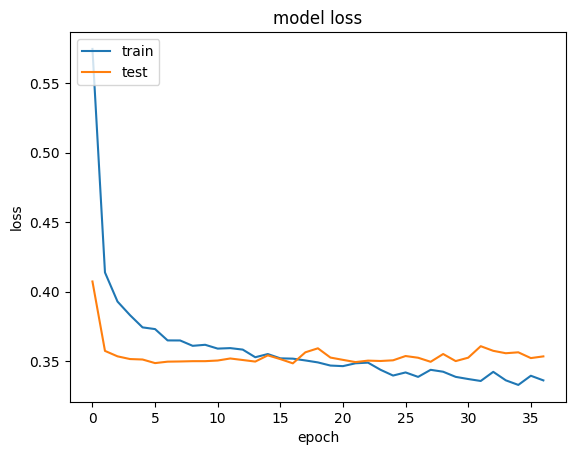

In [25]:
#summarise history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [26]:
# part 3- making the predictions and evaluating the model
y_pred=classifier.predict(x_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [27]:
# make the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1533,   60],
       [ 227,  180]])

In [28]:
## calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [29]:
score

0.8565

In [30]:
## get the weights
classifier.get_weights()

[array([[-1.42555818e-01,  1.74060270e-01,  4.17451173e-01,
         -3.90031964e-01, -9.24816206e-02, -1.01065010e-01,
          1.67551823e-02,  1.74919561e-01, -4.22656238e-02,
          2.21412137e-01,  2.09276974e-01, -4.53947484e-01,
          2.34664008e-01,  4.88075942e-01,  1.66043982e-01,
         -1.31236792e-01,  3.07577103e-01,  4.77011204e-02,
          1.23439971e-02,  1.14377573e-01,  3.54882300e-01,
         -1.74419016e-01, -7.05954432e-02, -2.69044459e-01,
         -1.22015230e-01],
        [ 4.79523242e-01, -3.88702601e-02,  5.09540021e-01,
          6.29740953e-02,  4.96915400e-01,  1.80457845e-01,
         -3.07027459e-01, -6.17654808e-02,  2.43980452e-01,
         -1.54965296e-01, -5.44045448e-01, -2.62777388e-01,
          1.56763360e-01, -4.42788787e-02, -4.49087173e-01,
          5.91606915e-01,  1.52510658e-01, -3.33255231e-01,
          5.87330222e-01,  1.95091829e-01, -1.50888667e-01,
          4.97614741e-01, -6.32550240e-01,  1.89479917e-01,
          1.7

## Evaluation: Catching Churners

Accuracy is misleading on this dataset (~20% churn base rate). A model that always predicts "no churn" scores ~80% — only 6 points below our model. The metrics that matter are **recall on the churn class** (how many churners we catch) and **PR-AUC** (precision-recall tradeoff across all thresholds).

In [31]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score,
                             precision_recall_curve, roc_curve)

y_prob = classifier.predict(x_test).ravel()

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}  (baseline = {y_test.mean():.2f})\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ROC-AUC : 0.8500
PR-AUC  : 0.6707  (baseline = 0.20)

              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.91      1593
     Churned       0.75      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



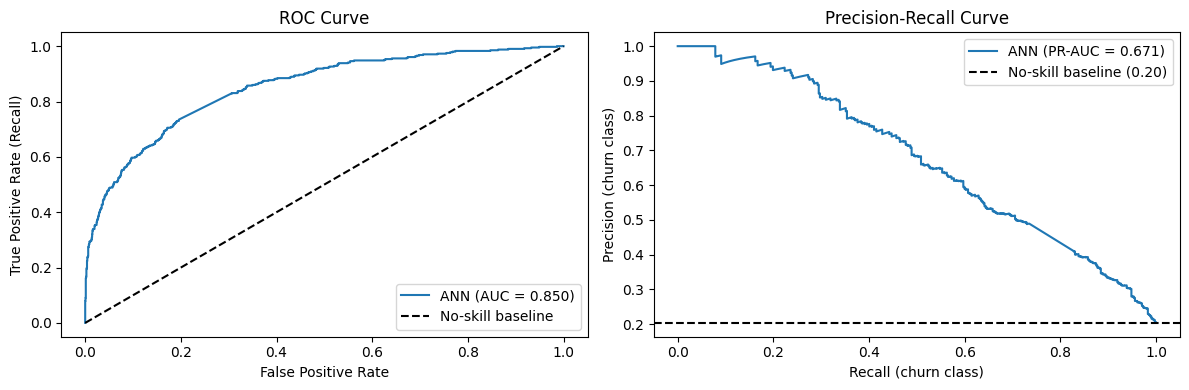

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, label=f"ANN (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label="No-skill baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, label=f"ANN (PR-AUC = {pr_auc:.3f})")
axes[1].axhline(y_test.mean(), color='k', linestyle='--', label=f"No-skill baseline ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall (churn class)")
axes[1].set_ylabel("Precision (churn class)")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

### Threshold Tuning

The default 0.5 threshold is not optimal for catching churners. Lowering it increases recall (fewer churners missed) at the cost of some precision (more false alarms). The F1 score finds the sweet spot.

Operating threshold : 0.208
Churn precision     : 0.512  (1 in 2.0 flagged customers is a true churner)
Churn recall        : 0.705  (71% of churners caught)

              precision    recall  f1-score   support

      Stayed       0.92      0.83      0.87      1593
     Churned       0.51      0.71      0.59       407

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.83      0.80      0.81      2000



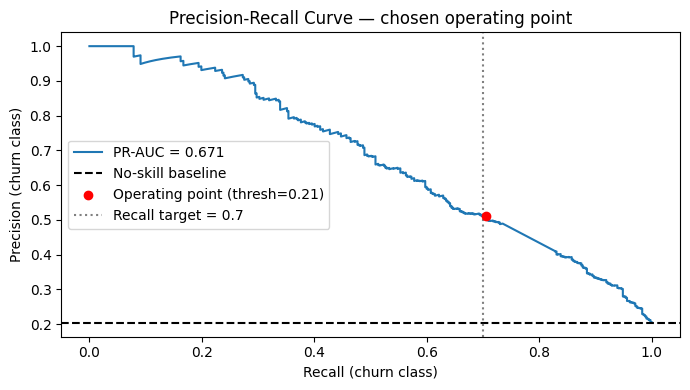

In [33]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Business assumption: missing a churner costs ~4× more than a false alarm
# (intervention cost << lifetime value of a retained customer).
# We therefore target recall >= 0.70 and, within that, maximise precision.
RECALL_TARGET = 0.70

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

# precision_recall_curve appends a final point with no matching threshold
p = precision_vals[:-1]
r = recall_vals[:-1]

feasible = r >= RECALL_TARGET
if feasible.any():
    best_idx  = np.argmax(p[feasible])          # highest precision among feasible
    best_t    = thresholds[feasible][best_idx]
    best_p    = p[feasible][best_idx]
    best_r    = r[feasible][best_idx]
else:
    best_idx  = np.argmax(r)
    best_t    = thresholds[best_idx]
    best_p    = p[best_idx]
    best_r    = r[best_idx]
    print(f"Warning: recall target {RECALL_TARGET} not achievable; using max-recall point.")

print(f"Operating threshold : {best_t:.3f}")
print(f"Churn precision     : {best_p:.3f}  (1 in {1/best_p:.1f} flagged customers is a true churner)")
print(f"Churn recall        : {best_r:.3f}  ({best_r*100:.0f}% of churners caught)")
print()

y_pred_tuned = (y_prob >= best_t).astype(int)
print(classification_report(y_test, y_pred_tuned, target_names=["Stayed", "Churned"]))

# Plot PR curve with the chosen operating point
plt.figure(figsize=(7, 4))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.3f}")
plt.axhline(y_test.mean(), color='k', linestyle='--', label="No-skill baseline")
plt.scatter([best_r], [best_p], color='red', zorder=5,
            label=f"Operating point (thresh={best_t:.2f})")
plt.axvline(RECALL_TARGET, color='grey', linestyle=':', label=f"Recall target = {RECALL_TARGET}")
plt.xlabel("Recall (churn class)")
plt.ylabel("Precision (churn class)")
plt.title("Precision-Recall Curve — chosen operating point")
plt.legend()
plt.tight_layout()
plt.show()

## Class Imbalance: Weighted Training

The dataset is ~80/20 (stayed/churned). Without correction the model leans toward predicting "stayed" because that's where most of the loss signal comes from. Passing `class_weight` to `.fit()` penalises missed churners ~4× more — no resampling, no data leakage.

In [34]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

# Compute weights from training labels
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"Class weights: {class_weight_dict}")

# Rebuild identical architecture
clf_w = Sequential([
    Dense(units=x_train.shape[1], activation='relu'),
    Dense(units=7,  activation='relu'),
    Dropout(0.2),
    Dense(units=6,  activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])
clf_w.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping_w = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', min_delta=0.0001, patience=20,
    verbose=0, restore_best_weights=True,
)

clf_w.fit(
    x_train, y_train,
    validation_split=0.33,
    batch_size=10,
    epochs=1000,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_w],
    verbose=0,
)
print("Training complete.")

Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}
Training complete.


In [35]:
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score

y_prob_w   = clf_w.predict(x_test).ravel()
y_pred_w   = (y_prob_w > 0.5).astype(int)

roc_auc_w  = roc_auc_score(y_test, y_prob_w)
pr_auc_w   = average_precision_score(y_test, y_prob_w)

print("=== Baseline (no class weighting) ===")
print(f"ROC-AUC: {roc_auc:.4f}  |  PR-AUC: {pr_auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

print("=== Weighted model ===")
print(f"ROC-AUC: {roc_auc_w:.4f}  |  PR-AUC: {pr_auc_w:.4f}")
print(classification_report(y_test, y_pred_w, target_names=["Stayed", "Churned"]))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Baseline (no class weighting) ===
ROC-AUC: 0.8500  |  PR-AUC: 0.6707
              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.91      1593
     Churned       0.75      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000

=== Weighted model ===
ROC-AUC: 0.8479  |  PR-AUC: 0.6690
              precision    recall  f1-score   support

      Stayed       0.91      0.84      0.87      1593
     Churned       0.52      0.66      0.58       407

    accuracy                           0.80      2000
   macro avg       0.71      0.75      0.73      2000
weighted avg       0.83      0.80      0.81      2000



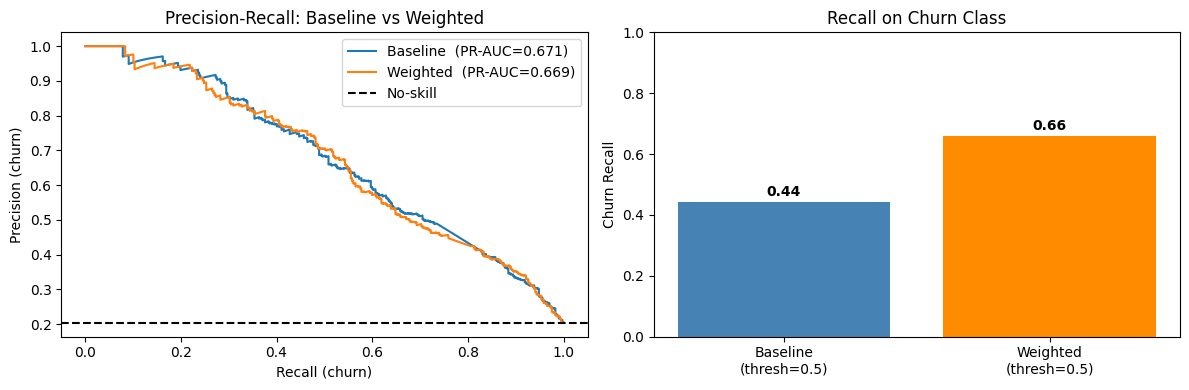

In [36]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PR curves: baseline vs weighted
p_b, r_b, _ = precision_recall_curve(y_test, y_prob)
p_w, r_w, _ = precision_recall_curve(y_test, y_prob_w)

axes[0].plot(r_b, p_b, label=f"Baseline  (PR-AUC={pr_auc:.3f})")
axes[0].plot(r_w, p_w, label=f"Weighted  (PR-AUC={pr_auc_w:.3f})")
axes[0].axhline(y_test.mean(), color='k', linestyle='--', label="No-skill")
axes[0].set_xlabel("Recall (churn)")
axes[0].set_ylabel("Precision (churn)")
axes[0].set_title("Precision-Recall: Baseline vs Weighted")
axes[0].legend()

# Recall bar chart (at default 0.5 threshold)
from sklearn.metrics import recall_score
recalls = {
    "Baseline\n(thresh=0.5)": recall_score(y_test, y_pred),
    "Weighted\n(thresh=0.5)": recall_score(y_test, y_pred_w),
}
axes[1].bar(recalls.keys(), recalls.values(), color=["steelblue", "darkorange"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Churn Recall")
axes[1].set_title("Recall on Churn Class")
for i, v in enumerate(recalls.values()):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Cross-Validation: PR-AUC Stability

A single 80/20 split is fragile — results depend on which customers land in the test set. Stratified 5-fold CV reports mean ± std of PR-AUC across folds, showing the model generalises rather than getting lucky on one split.

In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import average_precision_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf
import numpy as np

X_arr = np.array(x)
y_arr = np.array(y)

def build_model(n_features):
    m = Sequential([
        Dense(n_features, activation='relu'),
        Dense(7, activation='relu'),
        Dropout(0.2),
        Dense(6, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pr_aucs, roc_aucs = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_arr, y_arr), 1):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[train_idx], y_arr[val_idx]

    sc = StandardScaler()
    X_tr  = sc.fit_transform(X_tr)
    X_val = sc.transform(X_val)

    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
    cw_dict = {0: cw[0], 1: cw[1]}

    model = build_model(X_tr.shape[1])
    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
    )
    model.fit(X_tr, y_tr, validation_split=0.2, epochs=500, batch_size=32,
              class_weight=cw_dict, callbacks=[es], verbose=0)

    probs = model.predict(X_val, verbose=0).ravel()
    pr_aucs.append(average_precision_score(y_val, probs))
    roc_aucs.append(roc_auc_score(y_val, probs))
    print(f"Fold {fold}  PR-AUC={pr_aucs[-1]:.4f}  ROC-AUC={roc_aucs[-1]:.4f}")

print(f"\nPR-AUC  : {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")
print(f"ROC-AUC : {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")

Fold 1  PR-AUC=0.6741  ROC-AUC=0.8593
Fold 2  PR-AUC=0.6403  ROC-AUC=0.8316
Fold 3  PR-AUC=0.6848  ROC-AUC=0.8520
Fold 4  PR-AUC=0.6949  ROC-AUC=0.8485
Fold 5  PR-AUC=0.6786  ROC-AUC=0.8544

PR-AUC  : 0.6746 ± 0.0185
ROC-AUC : 0.8492 ± 0.0095


## Benchmark: XGBoost vs ANN

Tree-based models often outperform small ANNs on tabular data because they handle mixed scales, non-linear interactions, and class imbalance natively. Running XGBoost on the same features and CV protocol gives an honest comparison — either the ANN holds up (a real result) or the gap reveals something worth investigating.

In [38]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import numpy as np

X_arr = np.array(x)
y_arr = np.array(y)
feature_names = list(x.columns)

# scale_pos_weight mirrors class_weight='balanced' for XGBoost
neg, pos = (y_arr == 0).sum(), (y_arr == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}  (neg/pos ratio)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_pr, xgb_roc = [], []
importances_per_fold = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_arr, y_arr), 1):
    X_tr, X_val = X_arr[train_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[train_idx], y_arr[val_idx]

    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric='aucpr',
        early_stopping_rounds=30,
        random_state=42,
        verbosity=0,
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    probs = xgb.predict_proba(X_val)[:, 1]
    xgb_pr.append(average_precision_score(y_val, probs))
    xgb_roc.append(roc_auc_score(y_val, probs))
    importances_per_fold.append(xgb.feature_importances_)
    print(f"Fold {fold}  PR-AUC={xgb_pr[-1]:.4f}  ROC-AUC={xgb_roc[-1]:.4f}")

print(f"\nXGBoost  PR-AUC : {np.mean(xgb_pr):.4f} ± {np.std(xgb_pr):.4f}")
print(f"XGBoost  ROC-AUC: {np.mean(xgb_roc):.4f} ± {np.std(xgb_roc):.4f}")
print(f"\nANN (from CV above)")
print(f"ANN      PR-AUC : {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")
print(f"ANN      ROC-AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")

scale_pos_weight = 3.91  (neg/pos ratio)
Fold 1  PR-AUC=0.7078  ROC-AUC=0.8700
Fold 2  PR-AUC=0.6826  ROC-AUC=0.8587
Fold 3  PR-AUC=0.7125  ROC-AUC=0.8689
Fold 4  PR-AUC=0.7231  ROC-AUC=0.8686
Fold 5  PR-AUC=0.7134  ROC-AUC=0.8760

XGBoost  PR-AUC : 0.7079 ± 0.0136
XGBoost  ROC-AUC: 0.8684 ± 0.0056

ANN (from CV above)
ANN      PR-AUC : 0.6746 ± 0.0185
ANN      ROC-AUC: 0.8492 ± 0.0095


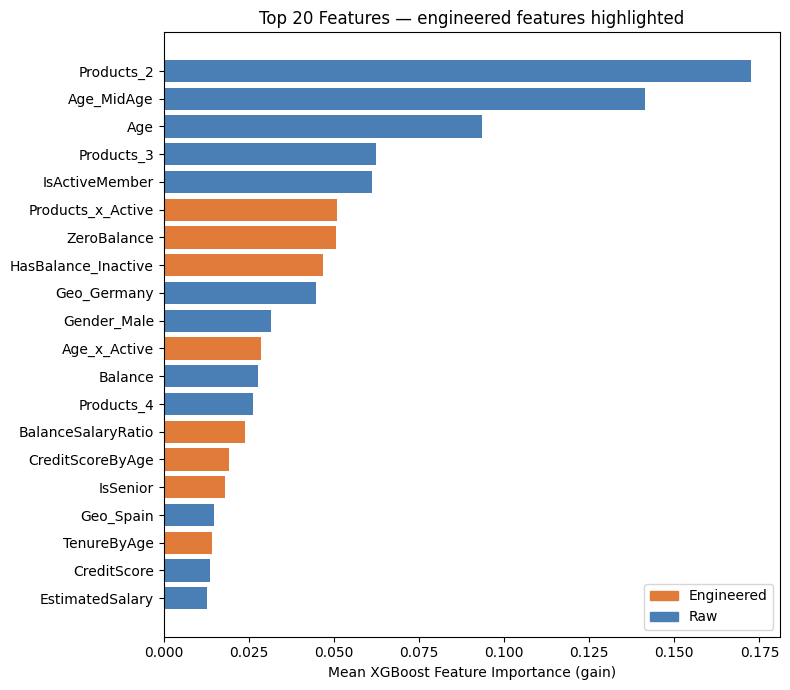


Engineered features in top 20:
['Products_x_Active', 'CreditScoreByAge', 'ZeroBalance', 'BalanceSalaryRatio', 'IsSenior', 'Age_x_Active', 'HasBalance_Inactive', 'TenureByAge']


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Average importances across folds, highlight engineered features
mean_imp = np.mean(importances_per_fold, axis=0)
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": mean_imp})
    .sort_values("importance", ascending=True)
    .tail(20)
)

engineered = {
    "BalanceSalaryRatio", "TenureByAge", "CreditScoreByAge",
    "ZeroBalance", "IsSenior", "IsNewCustomer",
    "HasBalance_Inactive", "Age_x_Active", "Products_x_Active",
}
colors = ["#e07b39" if f in engineered else "#4a7fb5" for f in imp_df["feature"]]

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(imp_df["feature"], imp_df["importance"], color=colors)
ax.set_xlabel("Mean XGBoost Feature Importance (gain)")
ax.set_title("Top 20 Features — engineered features highlighted")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#e07b39", label="Engineered"),
    Patch(color="#4a7fb5", label="Raw"),
])
plt.tight_layout()
plt.show()

print("\nEngineered features in top 20:")
top20 = set(imp_df["feature"])
print([f for f in engineered if f in top20])